# 1-Bit Neural Networks: Extreme Quantization

## What We'll Learn

We'll explore **1-bit neural networks**, where weights and activations are constrained to just a few values (typically {-1, +1} or {-1, 0, +1}). This extreme form of **quantization** dramatically reduces memory and computational requirements while maintaining competitive performance.

**Key intuitions we'll build:**
- Why 1-bit quantization works despite massive precision loss
- How to train networks with non-differentiable operations
- The tradeoffs between model size, speed, and accuracy
- How modern architectures like BitNet achieve state-of-the-art efficiency

**What we'll build:**
- Binary neural network layers from scratch
- Ternary (1.58-bit) networks inspired by BitNet
- Complete training pipeline with visualization of quantization effects
- Comparative analysis: 1-bit vs full precision

## 1. Setup

Import necessary libraries for building and visualizing 1-bit neural networks.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from aiml_notebooks import get_device, set_seed

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility and configure device.

In [2]:
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. Understanding Quantization

### What is Quantization?

**Quantization** is the process of mapping continuous values (like 32-bit floats) to a discrete set of values. 

Standard neural networks use 32-bit floats (~4 billion possible values). 1-bit quantization reduces this to just 2 or 3 values:
- **Binary**: {-1, +1} (1 bit per weight)
- **Ternary**: {-1, 0, +1} (1.58 bits per weight on average)

Let's see how much information we lose with quantization.

In [3]:
# Create a sample weight matrix with normal distribution
weights_fp32 = torch.randn(100, 100)

print(f"Full precision (FP32):")
print(f"  Range: [{weights_fp32.min():.4f}, {weights_fp32.max():.4f}]")
print(f"  Unique values: ~{weights_fp32.numel()}")
print(f"  Memory: {weights_fp32.element_size() * weights_fp32.numel()} bytes")
print(f"\nSample values: {weights_fp32.flatten()[:5].tolist()}")

Full precision (FP32):
  Range: [-3.8325, 4.2209]
  Unique values: ~10000
  Memory: 40000 bytes

Sample values: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232, 0.6784184575080872]


Now let's quantize these weights to binary values {-1, +1} using the sign function.

In [4]:
# Binary quantization: sign function
weights_binary = torch.sign(weights_fp32)

print(f"Binary (1-bit):")
print(f"  Range: [{weights_binary.min():.0f}, {weights_binary.max():.0f}]")
print(f"  Unique values: {len(weights_binary.unique())}")
print(f"  Memory (theoretical): {weights_fp32.numel() / 8} bytes (8x reduction)")
print(f"\nSample values: {weights_binary.flatten()[:5].tolist()}")

Binary (1-bit):
  Range: [-1, 1]
  Unique values: 2
  Memory (theoretical): 1250.0 bytes (8x reduction)

Sample values: [1.0, 1.0, 1.0, -1.0, 1.0]


Visualize the distribution shift from full precision to binary.

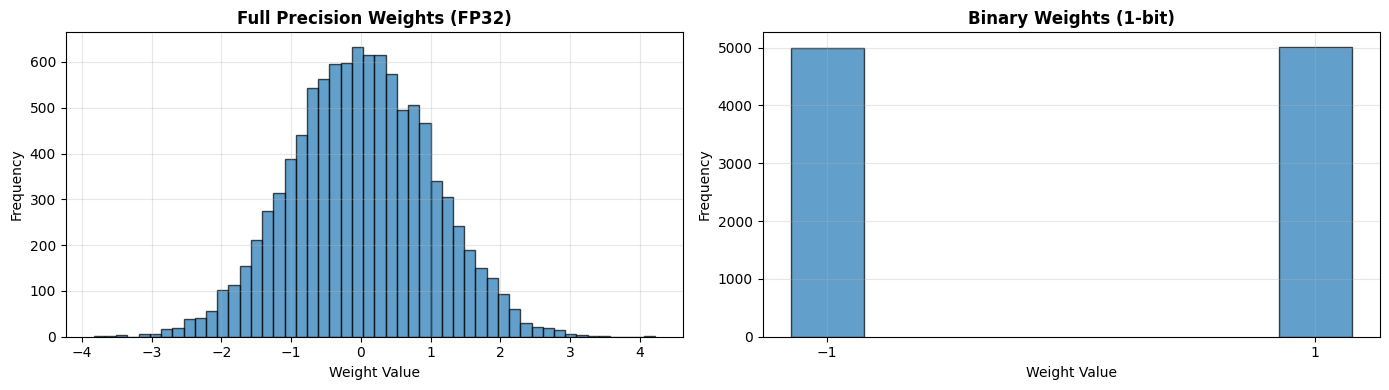

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Full precision distribution
ax1.hist(weights_fp32.flatten().numpy(), bins=50, alpha=0.7, edgecolor='black')
ax1.set_title('Full Precision Weights (FP32)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Weight Value')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# Binary distribution
unique, counts = torch.unique(weights_binary, return_counts=True)
ax2.bar(unique.numpy(), counts.numpy(), alpha=0.7, edgecolor='black', width=0.3)
ax2.set_title('Binary Weights (1-bit)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Weight Value')
ax2.set_ylabel('Frequency')
ax2.set_xticks([-1, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

We've reduced continuous values to just {-1, +1}, losing all magnitude information. Surprisingly, neural networks can still learn effectively with this constraint — the **sign** of weights matters more than their exact values for many tasks.

## 3. The Training Challenge: Non-Differentiable Functions

### The Problem

The sign function is **non-differentiable** at zero and has **zero gradient** everywhere else:

$$\text{sign}(x) = \begin{cases} -1 & \text{if } x < 0 \\ 0 & \text{if } x = 0 \\ +1 & \text{if } x > 0 \end{cases}$$

$$\frac{\partial \text{sign}(x)}{\partial x} = 0 \text{ (almost everywhere)}$$

This makes backpropagation impossible — gradients can't flow through the network!

Let's verify this.

In [6]:
# Test gradient flow through sign function
x = torch.tensor([0.5], requires_grad=True)
y = torch.sign(x)
y.backward()

print(f"Input: {x.item():.4f}")
print(f"Output (sign): {y.item():.4f}")
print(f"Gradient: {x.grad.item():.4f}")
print(f"\n⚠️  Gradient is zero — learning is impossible!")

Input: 0.5000
Output (sign): 1.0000
Gradient: 0.0000

⚠️  Gradient is zero — learning is impossible!


### The Solution: Straight-Through Estimator (STE)

The **straight-through estimator** is a clever trick:
- **Forward pass**: Use the quantized value (sign)
- **Backward pass**: Pretend it's the identity function (gradient = 1)

This approximation allows gradients to flow, enabling training.

Let's implement it.

In [7]:
class BinaryActivation(torch.autograd.Function):
    """Sign function with straight-through estimator for gradients."""
    
    @staticmethod
    def forward(ctx, input):
        # Forward: binarize using sign
        return torch.sign(input)
    
    @staticmethod
    def backward(ctx, grad_output):
        # Backward: pass gradient through as-is (identity)
        return grad_output

# Create a wrapper function
binary_activation = BinaryActivation.apply

Test that gradients now flow through our custom binary activation.

In [8]:
x = torch.tensor([0.5], requires_grad=True)
y = binary_activation(x)
y.backward()

print(f"Input: {x.item():.4f}")
print(f"Output (binary): {y.item():.4f}")
print(f"Gradient: {x.grad.item():.4f}")
print(f"\n✓ Gradient flows! Training is now possible.")

Input: 0.5000
Output (binary): 1.0000
Gradient: 1.0000

✓ Gradient flows! Training is now possible.


### Visualizing the Straight-Through Estimator

Let's visualize how the forward and backward passes differ.

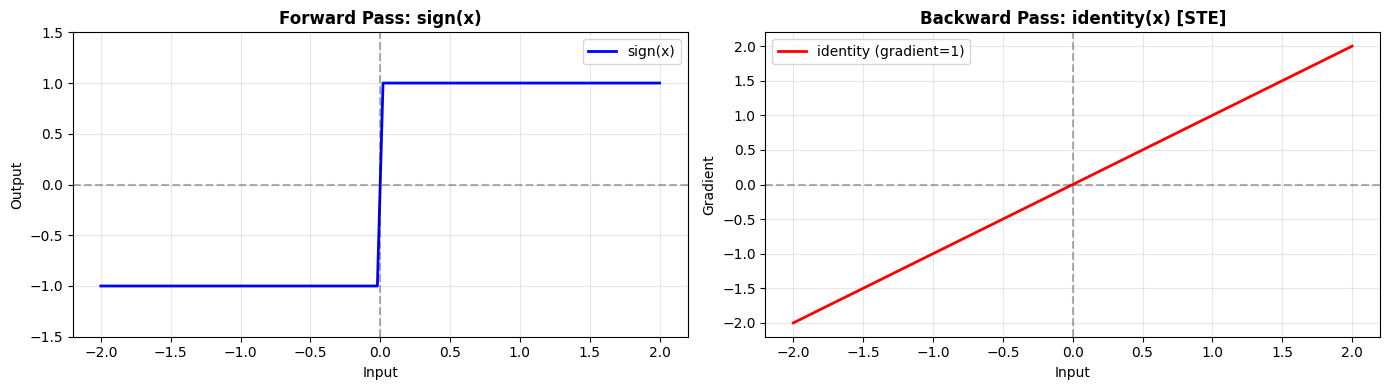

In [9]:
x_range = torch.linspace(-2, 2, 100)

# Forward pass
y_sign = torch.sign(x_range)
y_identity = x_range  # Backward approximation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Forward pass: sign function
ax1.plot(x_range.numpy(), y_sign.numpy(), 'b-', linewidth=2, label='sign(x)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax1.set_title('Forward Pass: sign(x)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Input')
ax1.set_ylabel('Output')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(-1.5, 1.5)

# Backward pass: identity (STE)
ax2.plot(x_range.numpy(), y_identity.numpy(), 'r-', linewidth=2, label='identity (gradient=1)')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax2.set_title('Backward Pass: identity(x) [STE]', fontsize=12, fontweight='bold')
ax2.set_xlabel('Input')
ax2.set_ylabel('Gradient')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Building a 1-Bit Linear Layer

### Binary Linear Layer

Now we'll build our first 1-bit component: a **binary linear layer**.

Key idea: Store full-precision weights internally, but quantize them during forward pass:
- $W_{\text{binary}} = \text{sign}(W_{\text{full}})$
- $y = W_{\text{binary}} \cdot x + b$

This allows gradients to update the full-precision weights during training.

In [10]:
class BinaryLinear(nn.Module):
    """Linear layer with binary weights {-1, +1}."""
    
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # Store full-precision weights for gradient updates
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        
    def forward(self, x):
        # Binarize weights during forward pass
        binary_weight = binary_activation(self.weight)
        
        # Standard linear operation with binary weights
        output = F.linear(x, binary_weight, self.bias)
        return output

Let's test our binary linear layer and verify it uses only {-1, +1} weights.

In [11]:
# Create a binary linear layer
layer = BinaryLinear(10, 5).to(device)

# Create sample input
x = torch.randn(2, 10).to(device)

# Forward pass
output = layer(x)

print(f"Full-precision weights (stored):")
print(f"  Shape: {layer.weight.shape}")
print(f"  Range: [{layer.weight.min():.4f}, {layer.weight.max():.4f}]")
print(f"  Sample: {layer.weight[0, :5].detach().cpu().tolist()}")

print(f"\nBinary weights (used in forward pass):")
binary_w = torch.sign(layer.weight)
print(f"  Unique values: {binary_w.unique().cpu().tolist()}")
print(f"  Sample: {binary_w[0, :5].cpu().tolist()}")

print(f"\nOutput shape: {output.shape}")

Full-precision weights (stored):
  Shape: torch.Size([5, 10])
  Range: [-2.1795, 2.7439]
  Sample: [-1.1723182201385498, 0.4068443179130554, -0.6165156960487366, -0.6136733889579773, 1.0867167711257935]

Binary weights (used in forward pass):
  Unique values: [-1.0, 1.0]
  Sample: [-1.0, 1.0, -1.0, -1.0, 1.0]

Output shape: torch.Size([2, 5])


## 5. Ternary Quantization (BitNet-style)

### Why Ternary?

Binary quantization {-1, +1} is extreme. **Ternary quantization** {-1, 0, +1} adds a third value (zero), which allows:
- Better expressiveness (weights can be "turned off")
- Sparsity benefits (zeros → skip computations)
- Only 1.58 bits per weight on average (still extremely efficient)

This is the approach used in **BitNet b1.58**, which achieves competitive performance with large language models.

Let's implement ternary quantization.

In [12]:
class TernaryActivation(torch.autograd.Function):
    """Ternary quantization {-1, 0, +1} with straight-through estimator."""

    @staticmethod
    def forward(ctx, input, threshold):
        # Quantize to {-1, 0, +1} based on threshold
        output = torch.zeros_like(input)
        output[input > threshold] = 1
        output[input < -threshold] = -1
        return output

    @staticmethod
    def backward(ctx, grad_output):
        # Straight-through: pass gradient as-is
        return grad_output, None

def ternary_activation(x, threshold=0.5):
    """Wrapper function for ternary activation with default threshold."""
    return TernaryActivation.apply(x, threshold)

Visualize how ternary quantization differs from binary.

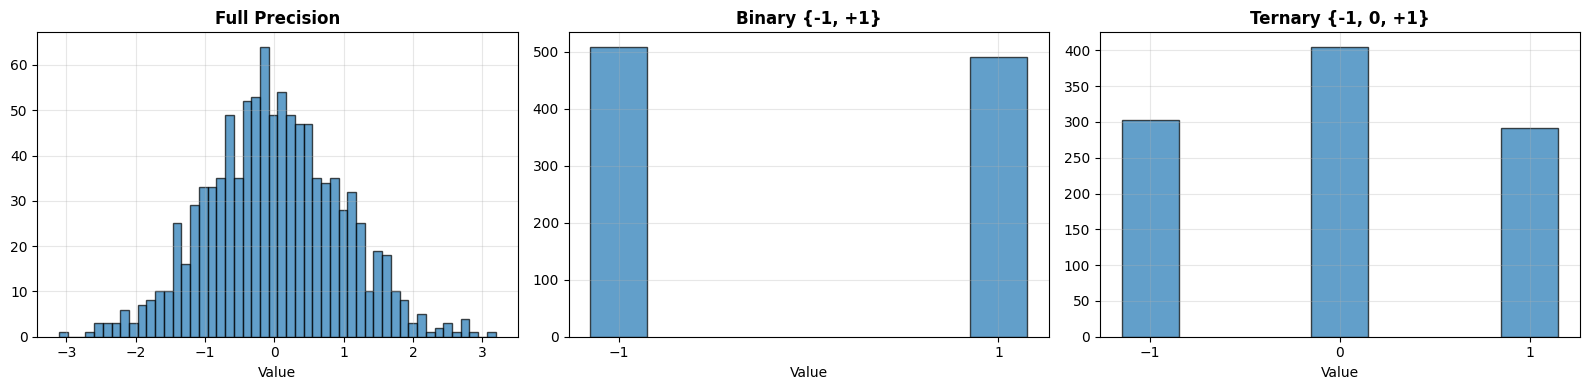

Ternary statistics:
  Zeros: 40.5%
  +1: 29.2%
  -1: 30.3%


In [13]:
# Sample weights
w = torch.randn(1000)
w_binary = binary_activation(w)
w_ternary = ternary_activation(w, threshold=0.5)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Original
axes[0].hist(w.numpy(), bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Full Precision', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].grid(True, alpha=0.3)

# Binary
unique, counts = torch.unique(w_binary, return_counts=True)
axes[1].bar(unique.numpy(), counts.numpy(), alpha=0.7, edgecolor='black', width=0.3)
axes[1].set_title('Binary {-1, +1}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].set_xticks([-1, 1])
axes[1].grid(True, alpha=0.3)

# Ternary
unique, counts = torch.unique(w_ternary, return_counts=True)
axes[2].bar(unique.numpy(), counts.numpy(), alpha=0.7, edgecolor='black', width=0.3)
axes[2].set_title('Ternary {-1, 0, +1}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].set_xticks([-1, 0, 1])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
zeros_pct = (w_ternary == 0).sum().item() / w_ternary.numel() * 100
print(f"Ternary statistics:")
print(f"  Zeros: {zeros_pct:.1f}%")
print(f"  +1: {(w_ternary == 1).sum().item() / w_ternary.numel() * 100:.1f}%")
print(f"  -1: {(w_ternary == -1).sum().item() / w_ternary.numel() * 100:.1f}%")

Now create a ternary linear layer.

In [14]:
class TernaryLinear(nn.Module):
    """Linear layer with ternary weights {-1, 0, +1}."""
    
    def __init__(self, in_features, out_features, threshold=0.5, bias=True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.threshold = threshold
        
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        
    def forward(self, x):
        # Ternarize weights
        ternary_weight = ternary_activation(self.weight, self.threshold)
        output = F.linear(x, ternary_weight, self.bias)
        return output

## 6. Building Complete 1-Bit Networks

### Simple Binary Network

Let's build a simple multi-layer binary network for classification. We'll use:
- Binary linear layers
- Batch normalization (stabilizes training)
- Standard ReLU activations (only weights are quantized)

In [15]:
class BinaryNet(nn.Module):
    """Simple binary neural network."""
    
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = BinaryLinear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = BinaryLinear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)  # Keep final layer full precision
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        
        x = self.fc3(x)
        return x

Create a ternary version for comparison.

In [16]:
class TernaryNet(nn.Module):
    """Simple ternary neural network (BitNet-style)."""
    
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = TernaryLinear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = TernaryLinear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        
        x = self.fc3(x)
        return x

And a standard full-precision baseline for comparison.

In [17]:
class FullPrecisionNet(nn.Module):
    """Standard full-precision neural network (baseline)."""
    
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        
        x = self.fc3(x)
        return x

## 7. Synthetic Dataset for Testing

Create a simple synthetic dataset: two interleaved spirals (non-linear classification problem).

In [18]:
def create_spiral_dataset(n_samples=1000, noise=0.1):
    """Create two interleaved spirals for binary classification."""
    n = n_samples // 2
    
    # Spiral 1
    theta1 = torch.linspace(0, 4 * np.pi, n)
    r1 = torch.linspace(0, 1, n)
    x1 = r1 * torch.cos(theta1) + torch.randn(n) * noise
    y1 = r1 * torch.sin(theta1) + torch.randn(n) * noise
    
    # Spiral 2 (rotated)
    theta2 = torch.linspace(0, 4 * np.pi, n) + np.pi
    r2 = torch.linspace(0, 1, n)
    x2 = r2 * torch.cos(theta2) + torch.randn(n) * noise
    y2 = r2 * torch.sin(theta2) + torch.randn(n) * noise
    
    # Combine
    X = torch.cat([torch.stack([x1, y1], dim=1), torch.stack([x2, y2], dim=1)])
    y = torch.cat([torch.zeros(n), torch.ones(n)]).long()
    
    # Shuffle
    indices = torch.randperm(n_samples)
    return X[indices], y[indices]

# Create dataset
X_train, y_train = create_spiral_dataset(1000, noise=0.1)
X_test, y_test = create_spiral_dataset(400, noise=0.1)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: torch.Size([1000, 2]), torch.Size([1000])
Test set: torch.Size([400, 2]), torch.Size([400])


Visualize the dataset to understand what we're working with.

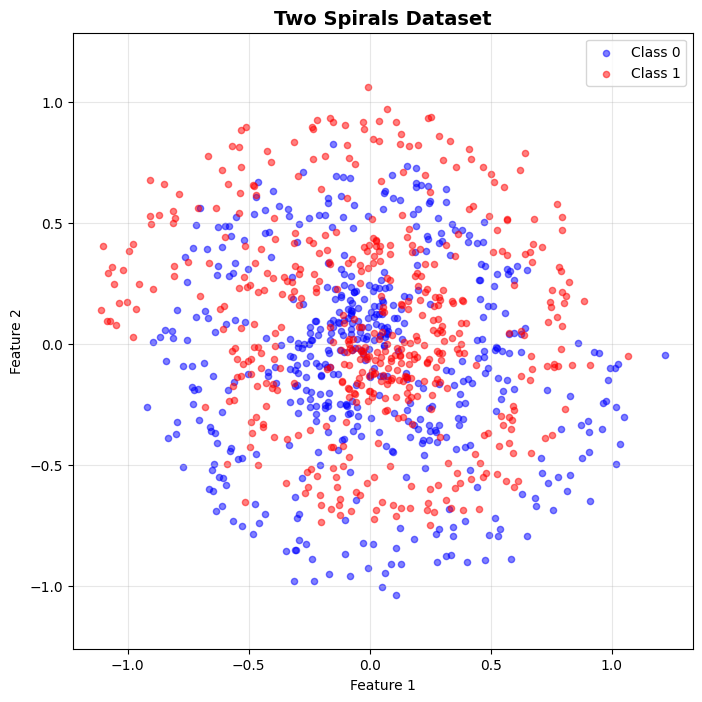

In [19]:
plt.figure(figsize=(8, 8))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
            c='blue', alpha=0.5, label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
            c='red', alpha=0.5, label='Class 1', s=20)
plt.title('Two Spirals Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Create data loaders for training.

In [20]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 8. Training Function

Create a reusable training function that works with any model.

In [21]:
def train_model(model, train_loader, test_loader, epochs=50, lr=0.01):
    """Train a model and return training history."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(y_batch).sum().item()
            train_total += y_batch.size(0)
        
        # Testing
        model.eval()
        test_loss = 0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                test_loss += loss.item() * X_batch.size(0)
                _, predicted = outputs.max(1)
                test_correct += predicted.eq(y_batch).sum().item()
                test_total += y_batch.size(0)
        
        # Record metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['test_loss'].append(test_loss / test_total)
        history['test_acc'].append(100. * test_correct / test_total)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {history['train_loss'][-1]:.4f}, "
                  f"Train Acc: {history['train_acc'][-1]:.2f}%, "
                  f"Test Acc: {history['test_acc'][-1]:.2f}%")
    
    return history

## 9. Comparative Experiment

### Train All Three Models

Now let's train all three models (full precision, binary, ternary) and compare their performance.

In [22]:
# Model hyperparameters
input_dim = 2
hidden_dim = 64
output_dim = 2
epochs = 50
lr = 0.01

print("Training Full Precision Model...")
model_fp = FullPrecisionNet(input_dim, hidden_dim, output_dim)
history_fp = train_model(model_fp, train_loader, test_loader, epochs=epochs, lr=lr)

Training Full Precision Model...


Epoch 10/50 - Train Loss: 0.6644, Train Acc: 57.60%, Test Acc: 56.75%


Epoch 20/50 - Train Loss: 0.6512, Train Acc: 59.20%, Test Acc: 55.25%


Epoch 30/50 - Train Loss: 0.6361, Train Acc: 61.60%, Test Acc: 56.50%


Epoch 40/50 - Train Loss: 0.6557, Train Acc: 58.50%, Test Acc: 57.50%


Epoch 50/50 - Train Loss: 0.6396, Train Acc: 61.20%, Test Acc: 62.50%


Train the binary model using the same training loop and compare results.

In [23]:
print("\nTraining Binary Model...")
model_bin = BinaryNet(input_dim, hidden_dim, output_dim)
history_bin = train_model(model_bin, train_loader, test_loader, epochs=epochs, lr=lr)


Training Binary Model...


Epoch 10/50 - Train Loss: 0.6633, Train Acc: 57.10%, Test Acc: 55.75%


Epoch 20/50 - Train Loss: 0.6472, Train Acc: 60.40%, Test Acc: 59.50%


Epoch 30/50 - Train Loss: 0.6148, Train Acc: 60.40%, Test Acc: 64.00%


Epoch 40/50 - Train Loss: 0.6347, Train Acc: 61.70%, Test Acc: 63.00%


Epoch 50/50 - Train Loss: 0.6591, Train Acc: 59.50%, Test Acc: 61.25%


Train the ternary model to see if the extra expressiveness from having zero weights improves performance.

In [24]:
print("\nTraining Ternary Model...")
model_tern = TernaryNet(input_dim, hidden_dim, output_dim)
history_tern = train_model(model_tern, train_loader, test_loader, epochs=epochs, lr=lr)


Training Ternary Model...


Epoch 10/50 - Train Loss: 0.6651, Train Acc: 59.30%, Test Acc: 55.50%


Epoch 20/50 - Train Loss: 0.6415, Train Acc: 60.10%, Test Acc: 56.25%


Epoch 30/50 - Train Loss: 0.6405, Train Acc: 61.70%, Test Acc: 62.75%


Epoch 40/50 - Train Loss: 0.6266, Train Acc: 62.60%, Test Acc: 63.75%


Epoch 50/50 - Train Loss: 0.6314, Train Acc: 64.90%, Test Acc: 67.25%


### Compare Learning Curves

Visualize how the three models learn over time.

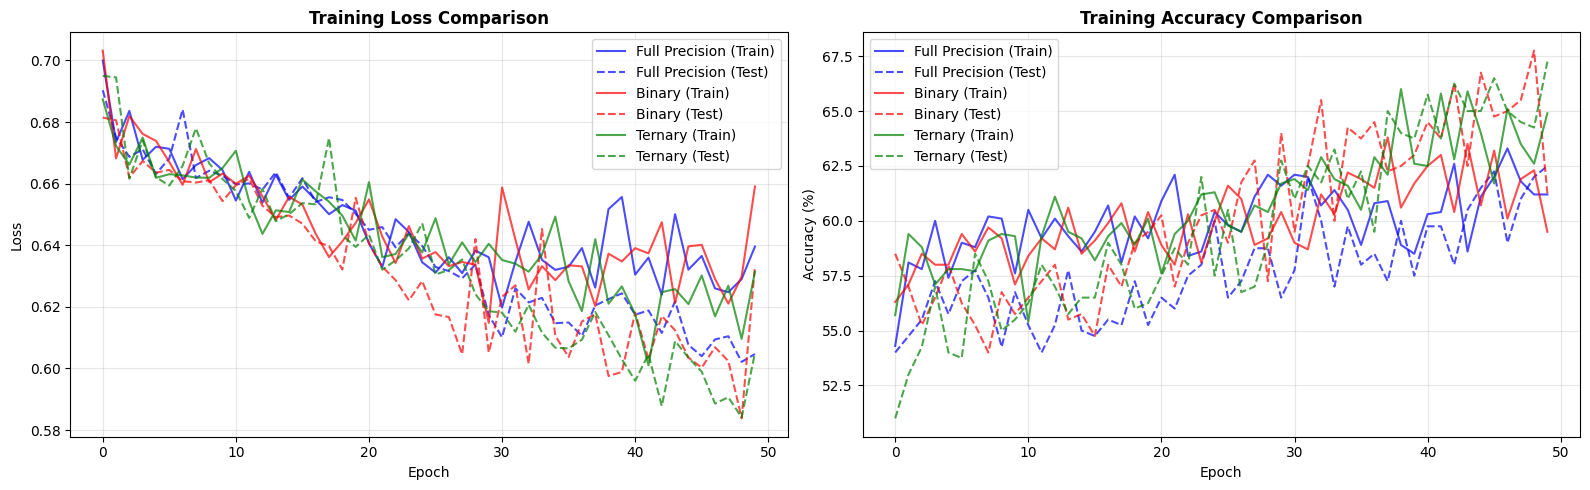

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
ax1.plot(history_fp['train_loss'], 'b-', label='Full Precision (Train)', alpha=0.7)
ax1.plot(history_fp['test_loss'], 'b--', label='Full Precision (Test)', alpha=0.7)
ax1.plot(history_bin['train_loss'], 'r-', label='Binary (Train)', alpha=0.7)
ax1.plot(history_bin['test_loss'], 'r--', label='Binary (Test)', alpha=0.7)
ax1.plot(history_tern['train_loss'], 'g-', label='Ternary (Train)', alpha=0.7)
ax1.plot(history_tern['test_loss'], 'g--', label='Ternary (Test)', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history_fp['train_acc'], 'b-', label='Full Precision (Train)', alpha=0.7)
ax2.plot(history_fp['test_acc'], 'b--', label='Full Precision (Test)', alpha=0.7)
ax2.plot(history_bin['train_acc'], 'r-', label='Binary (Train)', alpha=0.7)
ax2.plot(history_bin['test_acc'], 'r--', label='Binary (Test)', alpha=0.7)
ax2.plot(history_tern['train_acc'], 'g-', label='Ternary (Train)', alpha=0.7)
ax2.plot(history_tern['test_acc'], 'g--', label='Ternary (Test)', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy Comparison', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Print final metrics for easy comparison.

In [26]:
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"{'Model':<20} {'Test Accuracy':<15} {'Test Loss':<15}")
print("-"*60)
print(f"{'Full Precision':<20} {history_fp['test_acc'][-1]:>13.2f}% {history_fp['test_loss'][-1]:>14.4f}")
print(f"{'Binary (1-bit)':<20} {history_bin['test_acc'][-1]:>13.2f}% {history_bin['test_loss'][-1]:>14.4f}")
print(f"{'Ternary (1.58-bit)':<20} {history_tern['test_acc'][-1]:>13.2f}% {history_tern['test_loss'][-1]:>14.4f}")
print("="*60)


FINAL RESULTS
Model                Test Accuracy   Test Loss      
------------------------------------------------------------
Full Precision               62.50%         0.6047
Binary (1-bit)               61.25%         0.6333
Ternary (1.58-bit)           67.25%         0.6050


## 10. Decision Boundary Visualization

Visualize what each model has learned by plotting decision boundaries.

In [27]:
def plot_decision_boundary(model, X, y, title):
    """Plot decision boundary for a 2D classification model."""
    h = 0.02  # Step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    
    model.eval()
    with torch.no_grad():
        Z = model(grid).argmax(1).cpu().numpy()
    
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', alpha=0.6, s=20, edgecolor='k', linewidth=0.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', alpha=0.6, s=20, edgecolor='k', linewidth=0.5)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

Plot decision boundaries for all three models.

/tmp/ipykernel_27756/68941471.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
/tmp/ipykernel_27756/68941471.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


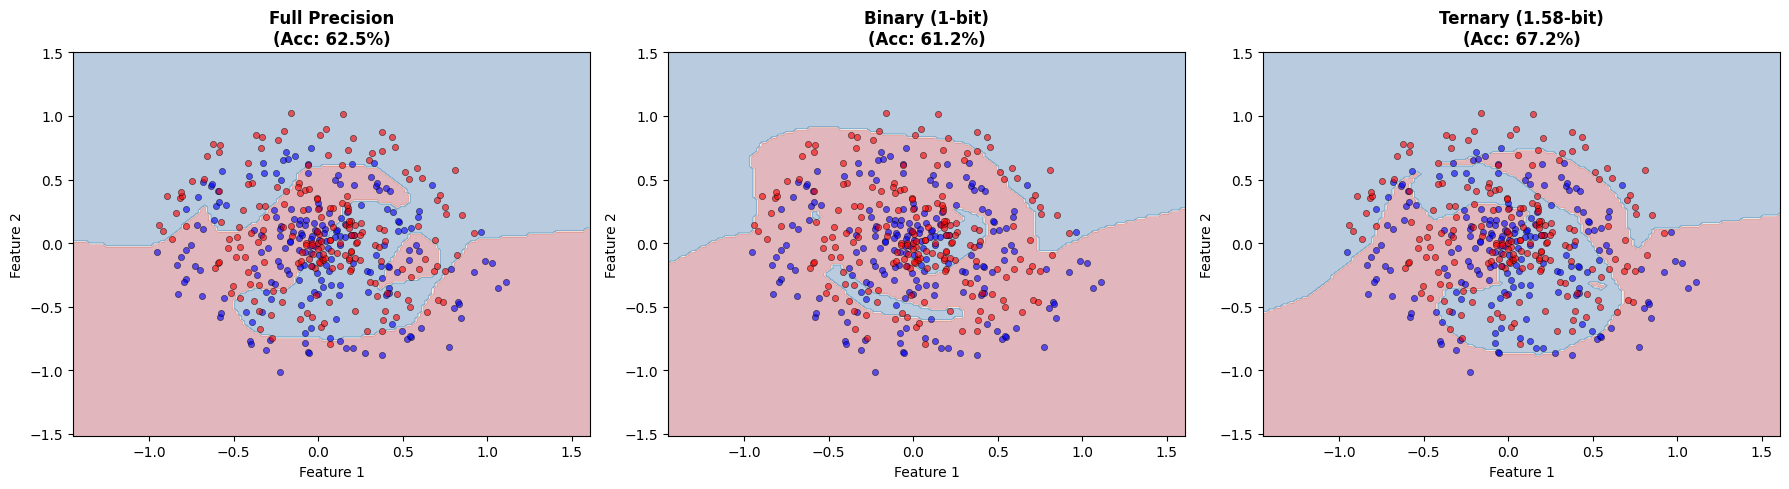

In [28]:
fig = plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_decision_boundary(model_fp, X_test, y_test, 
                       f'Full Precision\n(Acc: {history_fp["test_acc"][-1]:.1f}%)')

plt.subplot(1, 3, 2)
plot_decision_boundary(model_bin, X_test, y_test, 
                       f'Binary (1-bit)\n(Acc: {history_bin["test_acc"][-1]:.1f}%)')

plt.subplot(1, 3, 3)
plot_decision_boundary(model_tern, X_test, y_test, 
                       f'Ternary (1.58-bit)\n(Acc: {history_tern["test_acc"][-1]:.1f}%)')

plt.tight_layout()
plt.show()

### Key Insight

Despite using only {-1, +1} or {-1, 0, +1} for weights, 1-bit models can learn **complex non-linear decision boundaries** that are competitive with full precision models. The key is:
1. Maintaining full precision during gradient updates
2. Using the straight-through estimator
3. Batch normalization for stability

## 11. Memory and Efficiency Analysis

Calculate actual parameter counts and theoretical memory savings.

In [29]:
def count_parameters(model):
    """Count total and quantized parameters."""
    total = sum(p.numel() for p in model.parameters())
    quantized = 0
    
    for module in model.modules():
        if isinstance(module, (BinaryLinear, TernaryLinear)):
            quantized += module.weight.numel()
    
    return total, quantized

# Count parameters
fp_total, _ = count_parameters(model_fp)
bin_total, bin_quant = count_parameters(model_bin)
tern_total, tern_quant = count_parameters(model_tern)

print("\n" + "="*70)
print("PARAMETER COUNT & MEMORY ANALYSIS")
print("="*70)
print(f"{'Model':<20} {'Total Params':<15} {'Quantized':<15} {'Theoretical Mem':<20}")
print("-"*70)

fp_mem = fp_total * 4  # 4 bytes per FP32
bin_mem = (bin_total - bin_quant) * 4 + bin_quant / 8  # 1 bit per quantized weight
tern_mem = (tern_total - tern_quant) * 4 + tern_quant * 1.58 / 8  # 1.58 bits per quantized

print(f"{'Full Precision':<20} {fp_total:>14,} {0:>14,} {fp_mem/1024:>17.2f} KB")
print(f"{'Binary':<20} {bin_total:>14,} {bin_quant:>14,} {bin_mem/1024:>17.2f} KB")
print(f"{'Ternary':<20} {tern_total:>14,} {tern_quant:>14,} {tern_mem/1024:>17.2f} KB")

print("-"*70)
print(f"Binary memory reduction: {(1 - bin_mem/fp_mem)*100:.1f}%")
print(f"Ternary memory reduction: {(1 - tern_mem/fp_mem)*100:.1f}%")
print("="*70)


PARAMETER COUNT & MEMORY ANALYSIS
Model                Total Params    Quantized       Theoretical Mem     
----------------------------------------------------------------------
Full Precision                4,738              0             18.51 KB
Binary                        4,738          4,224              2.52 KB
Ternary                       4,738          4,224              2.82 KB
----------------------------------------------------------------------
Binary memory reduction: 86.4%
Ternary memory reduction: 84.7%


### Visualize the Efficiency-Accuracy Tradeoff

Create a scatter plot showing the relationship between model size and accuracy.

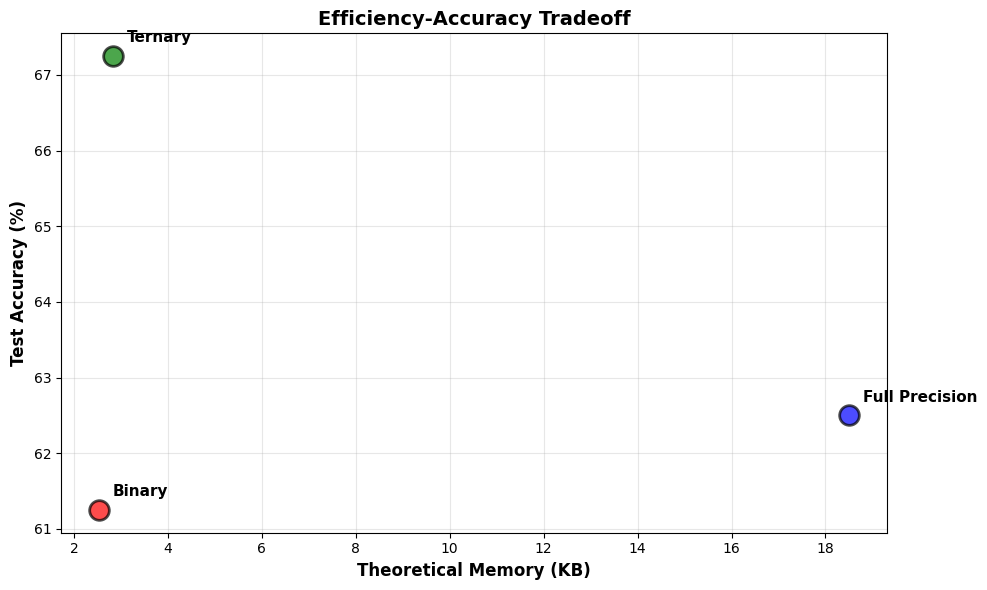

In [30]:
models_data = {
    'Full Precision': (fp_mem/1024, history_fp['test_acc'][-1]),
    'Binary': (bin_mem/1024, history_bin['test_acc'][-1]),
    'Ternary': (tern_mem/1024, history_tern['test_acc'][-1])
}

plt.figure(figsize=(10, 6))

for name, (mem, acc) in models_data.items():
    color = {'Full Precision': 'blue', 'Binary': 'red', 'Ternary': 'green'}[name]
    plt.scatter(mem, acc, s=200, alpha=0.7, c=color, edgecolor='black', linewidth=2)
    plt.annotate(name, (mem, acc), xytext=(10, 10), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.xlabel('Theoretical Memory (KB)', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Efficiency-Accuracy Tradeoff', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Visualizing Weight Distributions

Compare learned weight distributions across models.

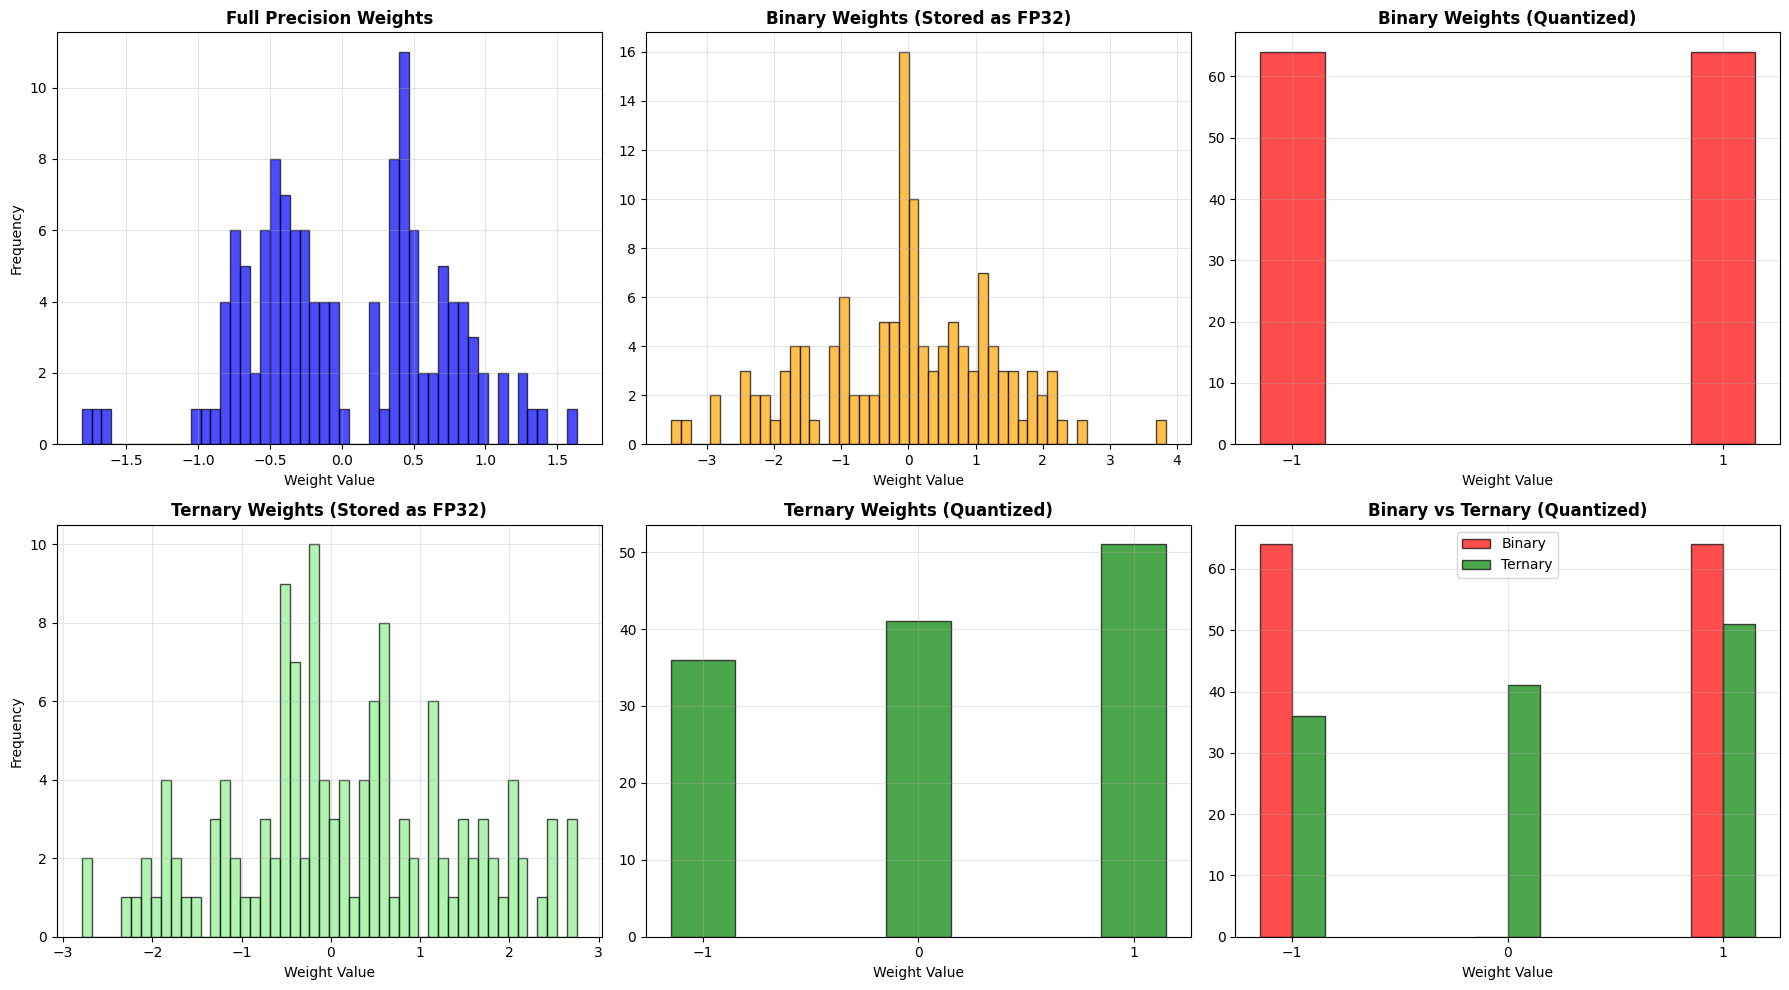


Ternary weight sparsity: 32.0% zeros
This means ~32.0% of computations can be skipped!


In [31]:
# Extract weights from first layer
fp_weights = model_fp.fc1.weight.detach().cpu().flatten()
bin_weights_full = model_bin.fc1.weight.detach().cpu().flatten()
bin_weights_quant = torch.sign(bin_weights_full)
tern_weights_full = model_tern.fc1.weight.detach().cpu().flatten()
tern_weights_quant = ternary_activation(tern_weights_full, threshold=0.5)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Full precision
axes[0, 0].hist(fp_weights.numpy(), bins=50, alpha=0.7, edgecolor='black', color='blue')
axes[0, 0].set_title('Full Precision Weights', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Weight Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Binary (stored)
axes[0, 1].hist(bin_weights_full.numpy(), bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].set_title('Binary Weights (Stored as FP32)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Weight Value')
axes[0, 1].grid(True, alpha=0.3)

# Binary (quantized)
unique, counts = torch.unique(bin_weights_quant, return_counts=True)
axes[0, 2].bar(unique.numpy(), counts.numpy(), alpha=0.7, edgecolor='black', color='red', width=0.3)
axes[0, 2].set_title('Binary Weights (Quantized)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Weight Value')
axes[0, 2].set_xticks([-1, 1])
axes[0, 2].grid(True, alpha=0.3)

# Ternary (stored)
axes[1, 0].hist(tern_weights_full.numpy(), bins=50, alpha=0.7, edgecolor='black', color='lightgreen')
axes[1, 0].set_title('Ternary Weights (Stored as FP32)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Weight Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Ternary (quantized)
unique, counts = torch.unique(tern_weights_quant, return_counts=True)
axes[1, 1].bar(unique.numpy(), counts.numpy(), alpha=0.7, edgecolor='black', color='green', width=0.3)
axes[1, 1].set_title('Ternary Weights (Quantized)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Weight Value')
axes[1, 1].set_xticks([-1, 0, 1])
axes[1, 1].grid(True, alpha=0.3)

# Comparison of quantized
unique_bin, counts_bin = torch.unique(bin_weights_quant, return_counts=True)
unique_tern, counts_tern = torch.unique(tern_weights_quant, return_counts=True)
width = 0.15
x = np.array([-1, 0, 1])
bin_heights = [counts_bin[unique_bin == v].item() if v in unique_bin else 0 for v in x]
tern_heights = [counts_tern[unique_tern == v].item() if v in unique_tern else 0 for v in x]
axes[1, 2].bar(x - width/2, bin_heights, width, alpha=0.7, label='Binary', edgecolor='black', color='red')
axes[1, 2].bar(x + width/2, tern_heights, width, alpha=0.7, label='Ternary', edgecolor='black', color='green')
axes[1, 2].set_title('Binary vs Ternary (Quantized)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Weight Value')
axes[1, 2].set_xticks([-1, 0, 1])
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
tern_zeros_pct = (tern_weights_quant == 0).sum().item() / tern_weights_quant.numel() * 100
print(f"\nTernary weight sparsity: {tern_zeros_pct:.1f}% zeros")
print(f"This means ~{tern_zeros_pct:.1f}% of computations can be skipped!")

## 13. Ablation: Effect of Threshold on Ternary Models

### Exploring the Threshold Hyperparameter

The **threshold** parameter in ternary quantization controls how many weights become zero. Let's experiment with different thresholds.

- Higher threshold → more zeros → more sparse (but potentially less expressive)
- Lower threshold → fewer zeros → less sparse (but more expressive)

In [32]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
threshold_results = []

for threshold in thresholds:
    print(f"\nTraining with threshold={threshold}...")
    model = TernaryNet(input_dim, hidden_dim, output_dim)
    # Update threshold for all ternary layers
    for module in model.modules():
        if isinstance(module, TernaryLinear):
            module.threshold = threshold
    
    history = train_model(model, train_loader, test_loader, epochs=30, lr=0.01)
    
    # Calculate sparsity
    with torch.no_grad():
        weights = model.fc1.weight
        quant_weights = ternary_activation(weights, threshold)
        sparsity = (quant_weights == 0).sum().item() / quant_weights.numel() * 100
    
    threshold_results.append({
        'threshold': threshold,
        'test_acc': history['test_acc'][-1],
        'sparsity': sparsity
    })
    
    print(f"Test Acc: {history['test_acc'][-1]:.2f}%, Sparsity: {sparsity:.1f}%")


Training with threshold=0.1...


Epoch 10/30 - Train Loss: 0.6579, Train Acc: 60.00%, Test Acc: 59.50%


Epoch 20/30 - Train Loss: 0.6429, Train Acc: 58.50%, Test Acc: 56.75%


Epoch 30/30 - Train Loss: 0.6316, Train Acc: 60.90%, Test Acc: 60.25%
Test Acc: 60.25%, Sparsity: 4.7%

Training with threshold=0.3...


Epoch 10/30 - Train Loss: 0.6640, Train Acc: 56.90%, Test Acc: 54.50%


...

Epoch 20/30 - Train Loss: 0.6480, Train Acc: 60.30%, Test Acc: 56.00%


Epoch 30/30 - Train Loss: 0.6403, Train Acc: 61.60%, Test Acc: 57.25%
Test Acc: 57.25%, Sparsity: 51.6%

Training with threshold=0.9...


Epoch 10/30 - Train Loss: 0.6630, Train Acc: 58.10%, Test Acc: 56.50%


Epoch 20/30 - Train Loss: 0.6413, Train Acc: 61.70%, Test Acc: 57.50%


Epoch 30/30 - Train Loss: 0.6349, Train Acc: 60.50%, Test Acc: 62.00%
Test Acc: 62.00%, Sparsity: 67.2%


Visualize the threshold sensitivity.

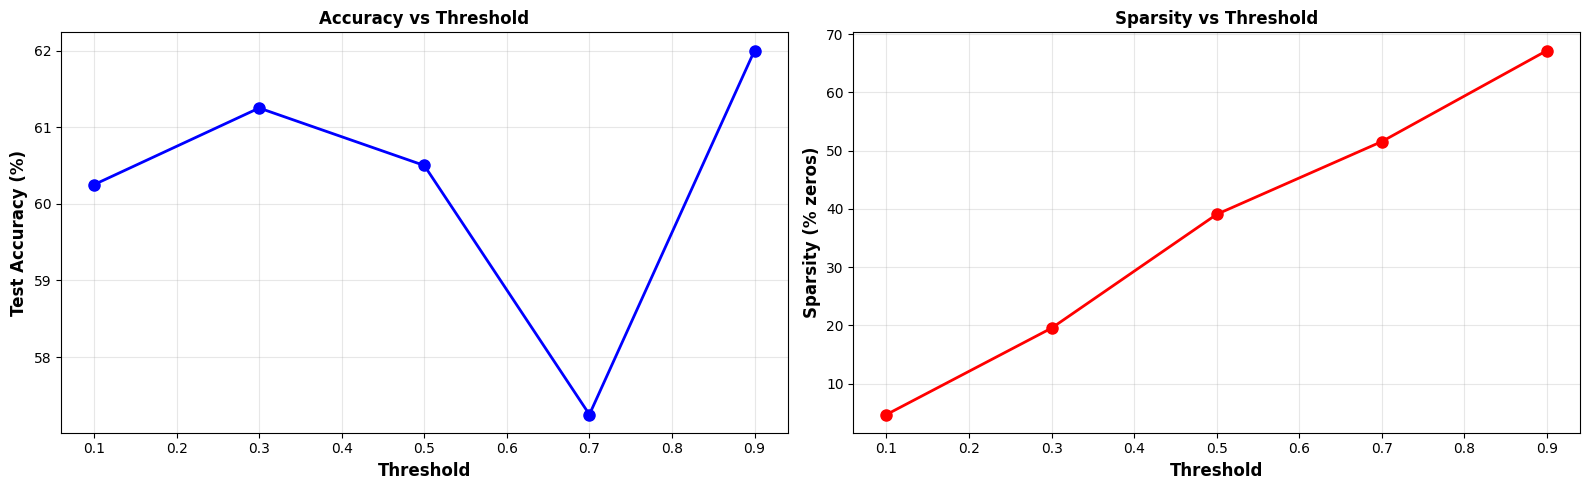

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

thresholds_list = [r['threshold'] for r in threshold_results]
accs = [r['test_acc'] for r in threshold_results]
sparsities = [r['sparsity'] for r in threshold_results]

# Accuracy vs threshold
ax1.plot(thresholds_list, accs, 'o-', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy vs Threshold', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Sparsity vs threshold
ax2.plot(thresholds_list, sparsities, 'o-', linewidth=2, markersize=8, color='red')
ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sparsity (% zeros)', fontsize=12, fontweight='bold')
ax2.set_title('Sparsity vs Threshold', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The threshold hyperparameter creates a **sparsity-accuracy tradeoff**:
- Very low thresholds → almost no sparsity, similar to binary
- Very high thresholds → too sparse, loss of expressiveness
- Sweet spot typically around 0.3-0.5 for this task

This is a crucial hyperparameter to tune for real-world applications.

## 14. Key Takeaways

### What We Learned

**1. Extreme Quantization Works**
- Reducing weights to {-1, +1} or {-1, 0, +1} can preserve most model performance
- The sign of weights matters more than their exact magnitude for many tasks
- Memory savings: 8-32x compared to FP32

**2. Straight-Through Estimator is Key**
- Forward pass: use quantized (discrete) values
- Backward pass: approximate gradients (identity function)
- This "trick" makes training non-differentiable functions possible

**3. Architecture Matters**
- Batch normalization stabilizes training with quantized weights
- Keep final layer full-precision for better calibration
- Internal full-precision storage allows gradient updates

**4. Ternary > Binary (Usually)**
- Adding zero {-1, 0, +1} provides better expressiveness than pure binary {-1, +1}
- Enables sparsity → potential computational savings
- Only 1.58 bits per weight (vs 1 bit for binary)

**5. Real-World Applications**
- BitNet models scale to billions of parameters
- 10x energy efficiency gains in large language models
- Enables on-device inference for large models
- Critical for edge computing and mobile deployment

**6. Tradeoffs to Consider**
- Small accuracy drop for massive efficiency gains
- Threshold tuning required for ternary models
- Training can be less stable than full precision
- Not all tasks benefit equally (some require more precision)

### Connections to Broader Concepts

- **Quantization-aware training**: Training with quantization constraints
- **Neural architecture search**: Finding efficient architectures
- **Lottery ticket hypothesis**: Sparse subnetworks can match full network performance
- **Knowledge distillation**: Compress large models into smaller ones
- **Efficient transformers**: BitNet applied to attention mechanisms

### Next Steps

To go deeper:
1. Try 1-bit activations (not just weights)
2. Implement BitNet's layer-specific scaling factors
3. Apply to convolutional or transformer architectures
4. Explore mixed-precision strategies (some layers quantized, others full)
5. Measure actual inference speed on hardware (not just parameter count)

## 15. References and Further Reading

**Key Papers:**
- **BitNet: Scaling 1-bit Transformers for Large Language Models** (2023) - Original BitNet paper
- **The Era of 1-bit LLMs: All Large Language Models are in 1.58 Bits** (2024) - BitNet b1.58
- **Binarized Neural Networks** (2016) - Foundational work on binary NNs
- **XNOR-Net: ImageNet Classification Using Binary Convolutional Neural Networks** (2016)

**Implementations:**
- Microsoft's BitNet.cpp - Efficient inference framework
- PyTorch quantization toolkit
- NVIDIA TensorRT for quantized inference

**Related Concepts:**
- Post-training quantization (PTQ)
- Quantization-aware training (QAT)  
- Mixed-precision training
- Pruning and sparsity